In [39]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 

In [40]:
df = pd.read_excel("Cleaned_Sales_Dataset.xlsx")

In [41]:
df.head()

,Order_ID,Customer_Name,Email,Category,Sales,Profit,Order_Date,Region,Quantity
0,1000,Pooja Desai,pooja.desai@gmail.com,Office Supplies,5008.07,506.457091,2025-10-19,West,10
1,1001,Divya Iyer,divya.iyer@gmail.com,Technology,3382.95,683.890000,2026-02-20,South,4
2,1002,Divya Iyer,divya.iyer@gmail.com,Furniture,4678.77,512.480000,2025-12-27,North,6
3,1003,Divya Iyer,divya.iyer@gmail.com,Furniture,5932.13,441.960000,2025-01-15,South,1
4,1004,Divya Iyer,divya.iyer@gmail.com,Office Supplies,9984.88,2269.580000,2025-08-13,West,2


In [42]:
df.shape

(1175, 9)

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1175 non-null   int64         
 1   Customer_Name  1175 non-null   str           
 2   Email          1175 non-null   str           
 3   Category       1175 non-null   str           
 4   Sales          1175 non-null   float64       
 5   Profit         1175 non-null   float64       
 6   Order_Date     1175 non-null   datetime64[us]
 7   Region         1175 non-null   str           
 8   Quantity       1175 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 82.7 KB


In [44]:
df.describe()

,Order_ID,Sales,Profit,Order_Date,Quantity
count,1175.000000,1175.000000,1175.000000,1175,1175.000000
mean,1599.331915,4940.110552,506.457091,2025-09-03 20:12:03.063829,5.464681
min,1000.000000,-4809.000000,-987.060000,2025-01-02 00:00:00,1.000000
25%,1299.500000,2541.720000,10.005000,2025-04-27 00:00:00,3.000000
50%,1599.000000,5008.360000,319.330000,2025-09-05 00:00:00,5.000000
75%,1899.500000,7400.680000,902.335000,2026-01-09 00:00:00,8.000000
max,2199.000000,9998.200000,2790.150000,2026-05-16 00:00:00,10.000000
std,347.216607,2943.974337,729.322626,NaN,2.850070


In [45]:
df.isnull().sum()

Order_ID         0
Customer_Name    0
Email            0
Category         0
Sales            0
Profit           0
Order_Date       0
Region           0
Quantity         0
dtype: int64

In [46]:
df["Category"].unique()

<StringArray>
['Office Supplies',      'Technology',       'Furniture', 'office supplies',
      'technology',       'furniture']
Length: 6, dtype: str

In [47]:
df["Category"].value_counts()

Category
Office Supplies    395
Furniture          383
Technology         367
technology          12
office supplies     10
furniture            8
Name: count, dtype: int64

In [48]:
df["Category"].dtype


<StringDtype(storage='python', na_value=nan)>

In [49]:
df["Category"] = (
    df["Category"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.title()
)

In [50]:
df["Category"].value_counts()

Category
Office Supplies    405
Furniture          391
Technology         379
Name: count, dtype: int64

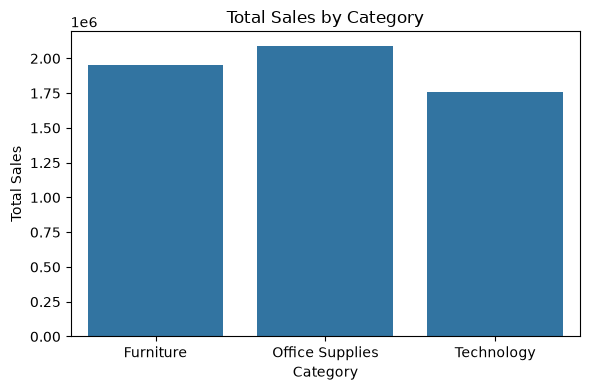

In [51]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=category_sales,
    x="Category",
    y="Sales"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [52]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

category_sales

,Category,Sales
0,Furniture,1.953171e+06
1,Office Supplies,2.090166e+06
2,Technology,1.761293e+06


In [53]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

region_sales

,Region,Sales
0,East,1.430095e+06
1,North,1.557255e+06
2,South,1.500633e+06
3,West,1.316647e+06


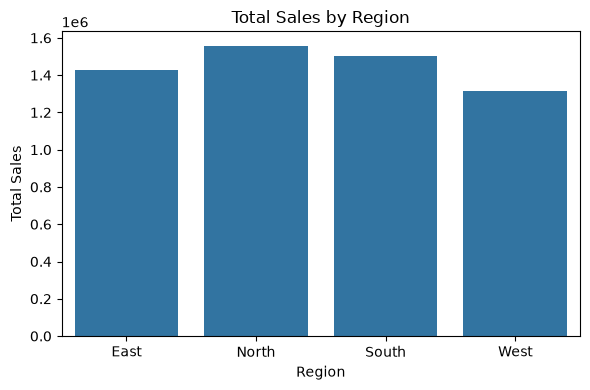

In [54]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=region_sales,
    x="Region",
    y="Sales"
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

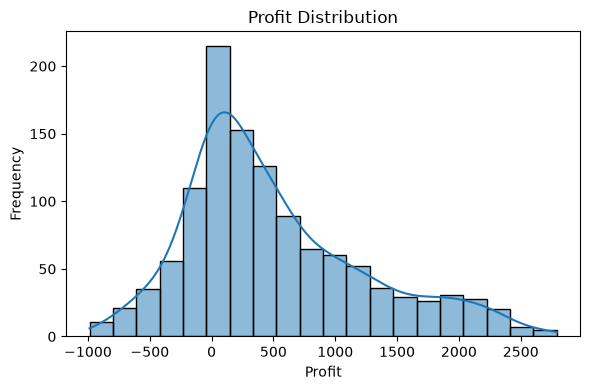

In [55]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="Profit",
    bins=20,
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

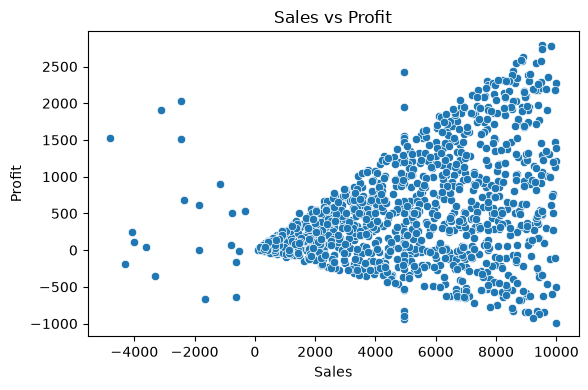

In [56]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [57]:
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

In [58]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

monthly_sales

,Month,Sales
0,2025-01,406775.512209
1,2025-02,286819.110000
2,2025-03,391383.081104
3,2025-04,383663.702209
4,2025-05,321450.230000
5,2025-06,329062.680552
6,2025-07,351167.880552
7,2025-08,314371.731104
8,2025-09,360870.160000
9,2025-10,459459.070552


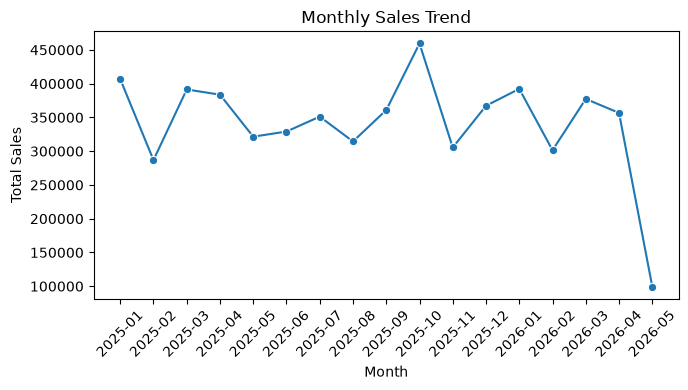

In [59]:
plt.figure(figsize=(7,4))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()